In [1]:
import numpy as np
from scipy.special import factorial
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt
import scipy as sp
from matplotlib.colors import SymLogNorm
import sys
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection/StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

20 phonons

In [2]:
nSiteData = np.load("data/nSite2DPlottingData.npz")
s_factor_nSite = nSiteData["s_tot"]
s_factor_nSite_incoh = nSiteData["s_diag"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]*1e6

In [3]:
qplt, omgplt= np.meshgrid(q_list_nSite,omega_list_nSite)

x = np.linspace(0.01,200,500)
y = x**2/2/26161e3
qbz = np.pi/(2*np.pi/2.28)
qia = 2*np.sqrt(2*13.13e-6*26161e3)
x_log = np.logspace(-2, 2.3,500)
y_dm = x_log*1e-3 - x_log**2/(80e3)

In [4]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

Text(0.5, 0, '$q$ [keV]')

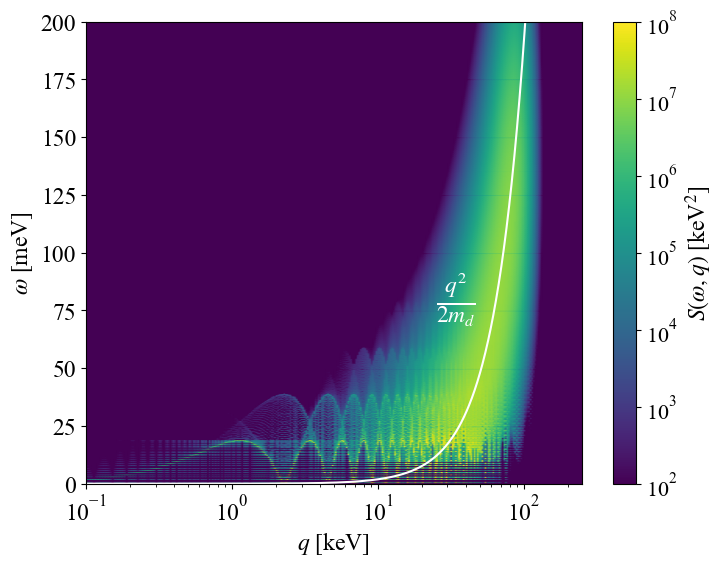

In [5]:
plt.figure(figsize=(8, 6),)
pcm = plt.pcolormesh(qplt, omgplt, s_factor_nSite.T,shading='gouraud',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("$S(\omega,q)$ [keV$^2$]")
cbar.ax.tick_params(labelsize=16)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
# plt.plot(x_log,y_dm*1e6, color='white', linestyle=":")
# plt.axvline(qbz,color="gray",linestyle="--",)
# plt.axvline(qia,color="gray",linestyle="--",)
# plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
# plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.xscale('log')
plt.xlim(1e-1,250)
plt.ylim(0,200)
plt.clim(1e2,1e8)
plt.text(25,75,r"$\frac{q^2}{2m_d}$",color="white",fontsize = 24)
plt.ylabel("$\omega$ [meV]")
plt.xlabel("$q$ [keV]")
 # plt.legend()
# plt.yscale('log')

Text(0.5, 1.0, 'Incoherent approximation')

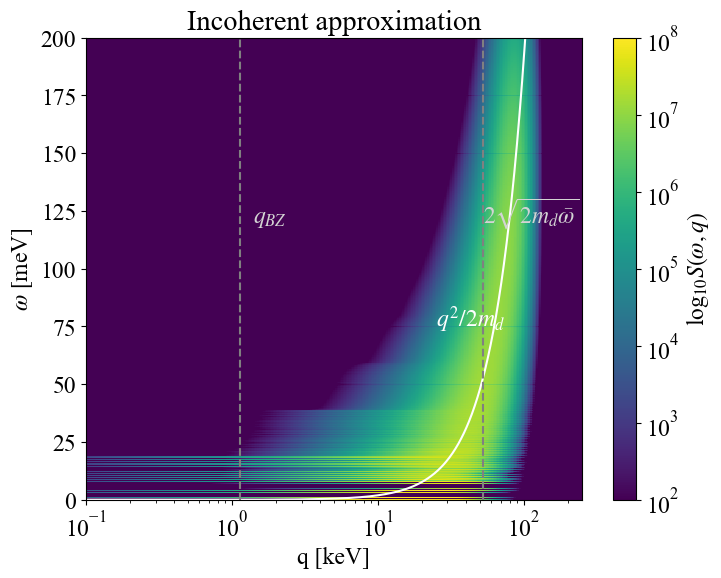

In [6]:
plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt, omgplt, s_factor_nSite_incoh.T,shading='nearest',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
plt.xscale('log')
plt.clim(1e2,1e8)
plt.xlim(1e-1,250)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
plt.text(25,75,"$q^2/2m_d$",color="white")
plt.axvline(qbz,color="gray",linestyle="--",)
plt.axvline(qia,color="gray",linestyle="--",)
plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.ylabel("$\omega$ [meV]")
plt.ylim(0,200)
plt.xlabel("q [keV]")
plt.title("Incoherent approximation")
# plt.yscale('log')

In [7]:
def get_impulse_approx(q, omega_list, omega_avg=13.13e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)

In [8]:
s_factor_IA = get_impulse_approx(q_list_nSite[:,np.newaxis], omega_list_nSite*1e-6, omega_avg=13.13e-6)
s_factor_IA.shape

(600, 700)

Text(0.5, 1.0, 'Impulse Approximation')

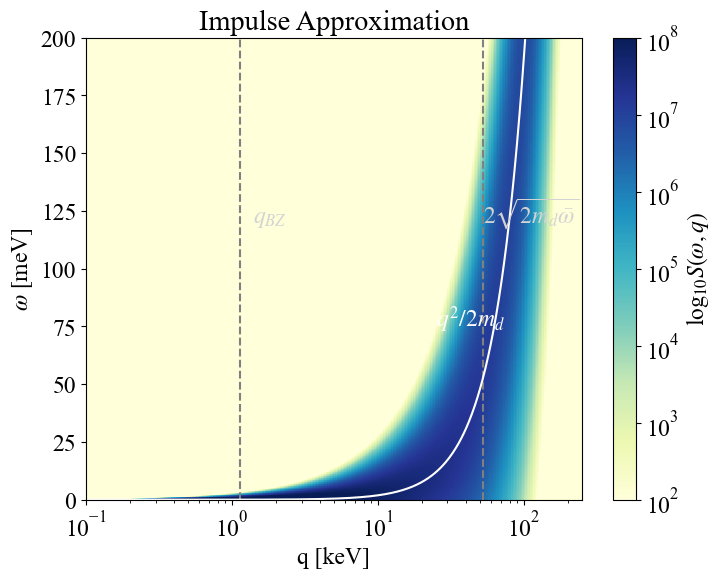

In [9]:
plt.figure(figsize=(8, 6))
pcm = plt.pcolormesh(qplt, omgplt, s_factor_IA.T,shading='nearest',cmap='YlGnBu',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
cbar = plt.colorbar(pcm, )
cbar.set_label("log$_{10}S(\omega,q)$")
plt.xscale('log')
plt.xlim(1e-1,250)
plt.axvline(qbz,color="gray",linestyle="--",)
plt.axvline(qia,color="gray",linestyle="--",)
plt.text(1.4,120,r"$q_{BZ}$",color="lightgray")
plt.text(qia,120,r"$2\sqrt{2m_d\bar{\omega}}$",color="lightgray")
plt.clim(1e2,1e8)
plt.plot(x,y*1e6, color='white', label="q^2/2m")
plt.text(25,75,"$q^2/2m_d$",color="white")
plt.ylabel("$\omega$ [meV]")
plt.ylim(0,200)
plt.xlabel("q [keV]")
plt.title("Impulse Approximation")

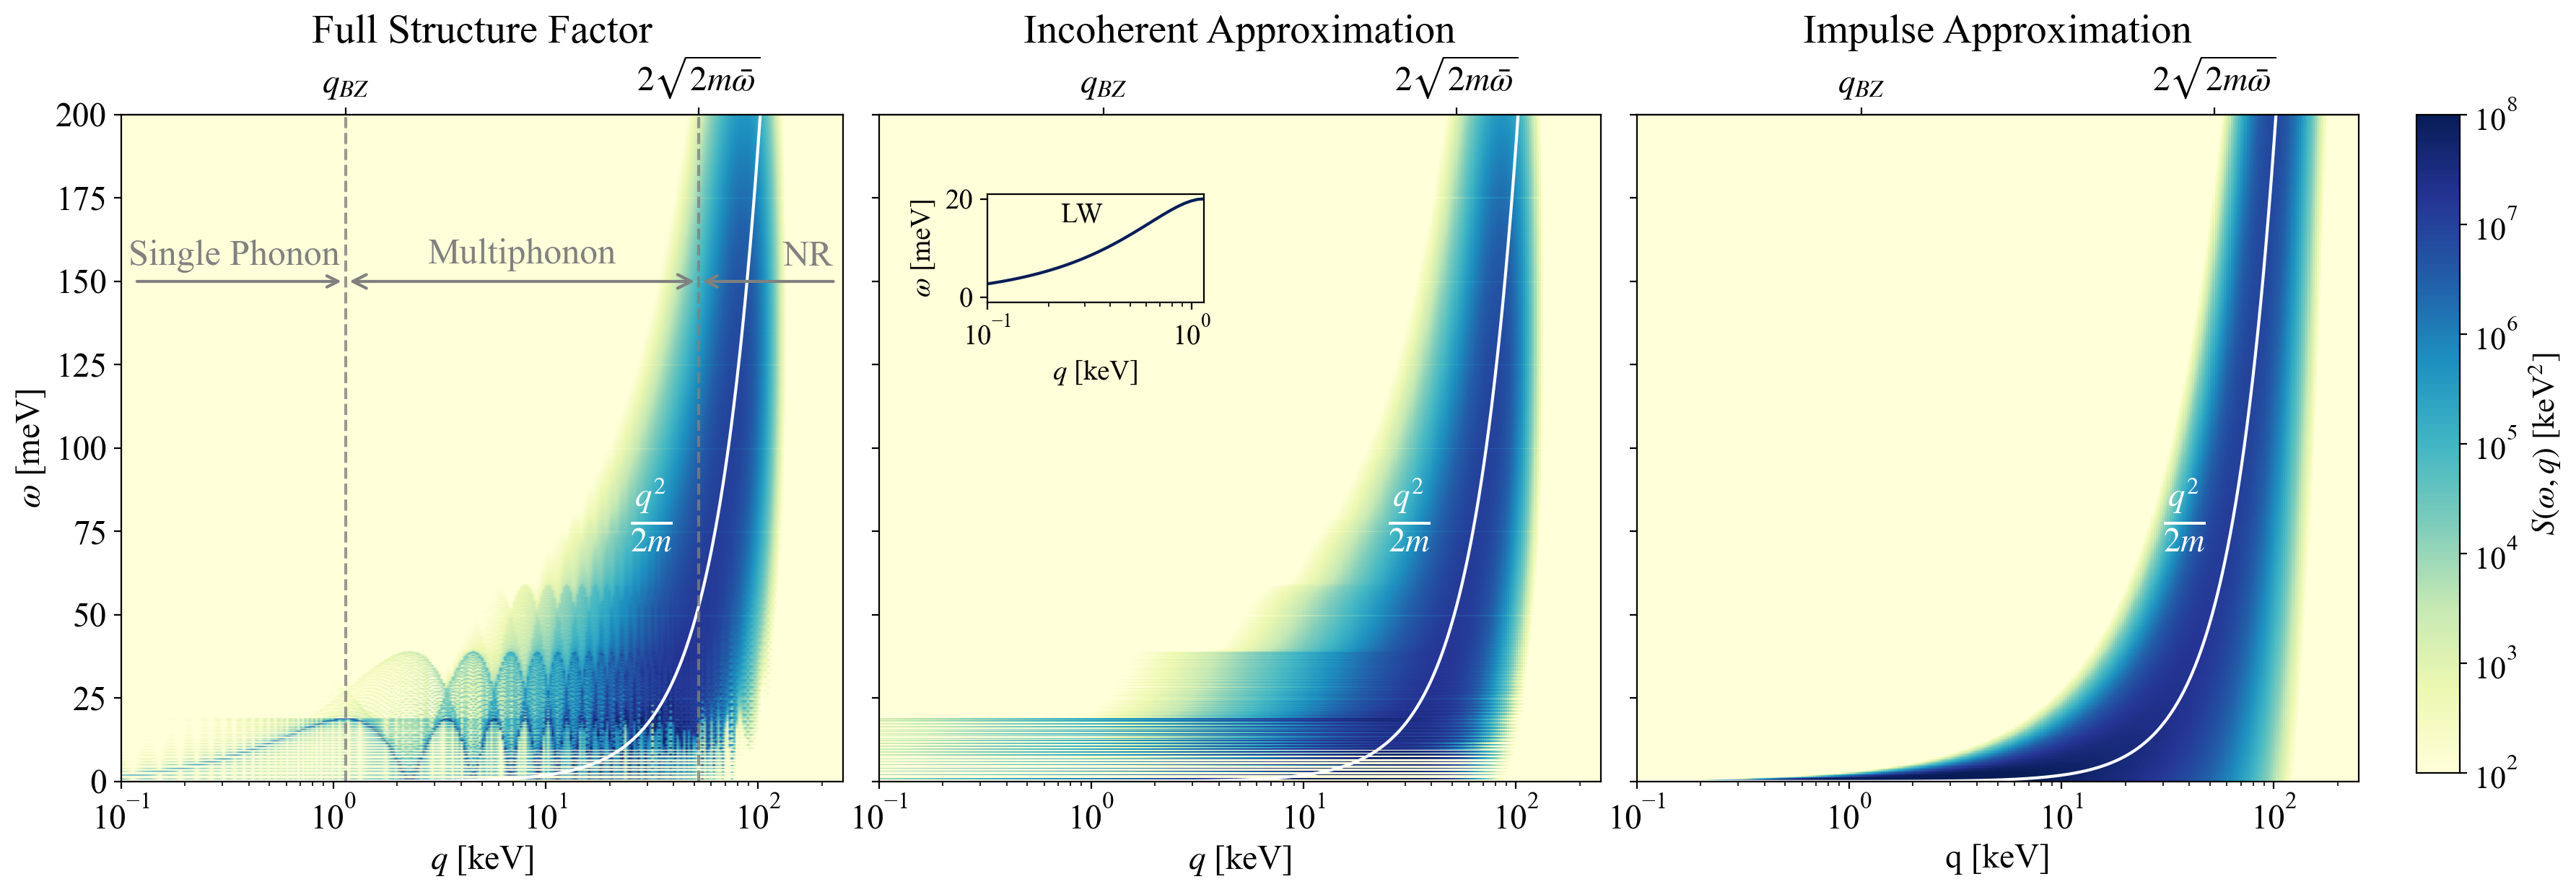

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, dpi=200)

# Define shared normalization
norm = SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8)


pcm1 = axes[2].pcolormesh(qplt, omgplt, s_factor_IA.T,cmap='YlGnBu', shading='nearest', norm=norm)
pcm1.set_clim(1e2, 1e8)
axes[2].set_xscale('log')
axes[2].set_xlim(1e-1, 250)
axes[2].set_ylim(0, 200)
axes[2].plot(x, y*1e6, color='white', label="q^2/2m")
axes[2].text(30, 75, r"$\frac{q^2}{2m}$", color="white",fontsize=24)

axes[0].set_ylabel(r"$\omega$ [meV]")
axes[2].set_xlabel("q [keV]")
axes[2].set_title("Impulse Approximation")


pcm2 = axes[1].pcolormesh(qplt, omgplt, s_factor_nSite_incoh.T, cmap='YlGnBu', shading='nearest', norm=norm)
pcm2.set_clim(1e2, 1e8)
axes[1].set_xscale('log')
axes[1].set_xlim(1e-1, 250)
axes[1].set_ylim(0, 200)
axes[1].plot(x, y*1e6, color='white', label="q^2/2m")
axes[1].text(25, 75, r"$\frac{q^2}{2m}$", color="white",fontsize=24)

axes[1].set_xlabel("$q$ [keV]")
axes[1].set_title("Incoherent Approximation")



pcm3 = axes[0].pcolormesh(qplt, omgplt, s_factor_nSite.T, shading='gouraud',cmap='YlGnBu', norm=norm)
pcm3.set_clim(1e2, 1e8)
axes[0].set_xscale('log')
axes[0].set_xlim(1e-1, 250)
axes[0].set_ylim(0, 200)
axes[0].plot(x, y*1e6, color='white', label="q^2/2m")
axes[0].text(25, 75, r"$\frac{q^2}{2m}$", color="white", fontsize=24)
axes[0].set_xlabel("$q$ [keV]")
axes[0].set_title('Full Structure Factor')



fig.subplots_adjust(wspace=0.05)

cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.76]) 

# Draw the colorbar into this specific axis
cbar = fig.colorbar(pcm3, cax=cbar_ax)
cbar.set_label("$S(\omega,q)$ [keV$^2$]", fontsize=16)
cbar.ax.tick_params(labelsize=16)


secax0 = axes[0].secondary_xaxis('top')
secax0.set_xticks([qbz, qia])
secax0.set_xticklabels([r"$q_{BZ}$", r"$2\sqrt{2m\bar{\omega}}$"])
secax0.minorticks_off()
secax0.tick_params(axis='x',)

secax1 = axes[1].secondary_xaxis('top')
secax1.set_xticks([qbz, qia])
secax1.set_xticklabels([r"$q_{BZ}$", r"$2\sqrt{2m\bar{\omega}}$"])
secax1.minorticks_off()
secax1.tick_params(axis='x',)

secax2 = axes[2].secondary_xaxis('top')
secax2.set_xticks([qbz, qia])
secax2.set_xticklabels([r"$q_{BZ}$", r"$2\sqrt{2m\bar{\omega}}$"])
secax2.minorticks_off()
secax2.tick_params(axis='x',)

y_ann = 150 
# Vertical threshold lines
axes[0].axvline(x=qbz, color='gray', linestyle='--', alpha=0.8)
axes[0].axvline(x=qia, color='gray', linestyle='--', alpha=0.8)

# 1. Pointing left (< x1)
axes[0].annotate('', xy=(qbz * 0.1, y_ann), xytext=(qbz, y_ann),
                 color='gray', ha='right', va='center', fontsize=14,
                 arrowprops=dict(arrowstyle='<-', color='gray', lw=1.5))
axes[0].text(qbz/10.5, y_ann+5, "Single Phonon", color="gray", fontsize=18)
# 2. Pointing between x1 and x2 
# Using geometric mean for the visual center since the x-axis is on a log scale
x_mid = (qbz * qia)**0.5  
axes[0].annotate('', xy=(qbz, y_ann), xytext=(qia, y_ann),
                 arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
axes[0].text(x_mid, y_ann + 3, 'Multiphonon', color='gray', ha='center', va='bottom', fontsize=18)

# 3. Pointing right (> x2)
axes[0].annotate('', xy=(qia * 4.5, y_ann), xytext=(qia , y_ann),
                 color='gray', ha='right', va='center', fontsize=14,
                 arrowprops=dict(arrowstyle='<-', color='gray', lw=1.5))
axes[0].text(qia*2.5, y_ann+5, "NR",color="gray", fontsize=18)
# -----------------------------------------

axins = axes[1].inset_axes([0.15, 0.65, 0.3, 0.3]) 

# Get the YlGnBu colormap to extract specific colors
cmap = plt.get_cmap('YlGnBu')
yellowest = cmap(0.0) # Lowest end of the colormap
bluest = cmap(1.0)    # Highest end of the colormap

# Placeholder function data
x_inset = np.geomspace(0.001, qbz, 100)
y_inset = 20*np.sin(x_inset*2*np.pi/2.28/2)
axins.set_xscale("log")
axins.set_xlim(0.1, qbz)
axins.set_box_aspect(.5)
axins.set_ylabel(r"$\omega$ [meV]", fontsize=14)
axins.set_xlabel("$q$ [keV]", fontsize=14)
# Plot on the inset using the bluest color
axins.plot(x_inset, y_inset, color=bluest, lw=1.5)
axins.set_title("LW    ", color="black", fontsize=14, y=1., pad=-14)
axins.tick_params(axis='both', which='major', labelsize=14, colors="black") # Changed tick colors to black for visibility against yellow

# Set the inset background to the yellowest color
axins.set_facecolor(yellowest)

plt.show()

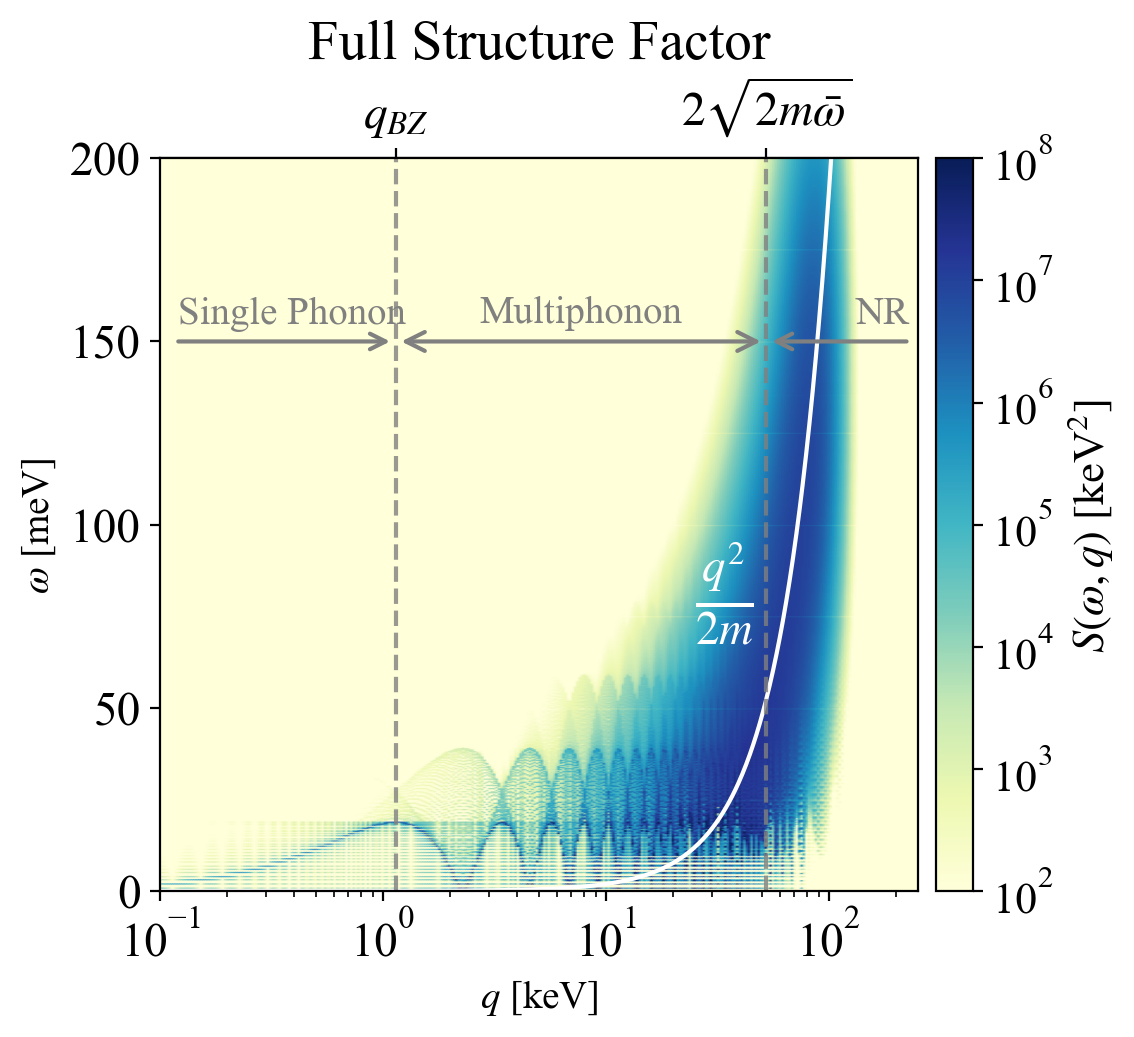

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import numpy as np

# Assuming your data variables (qplt, omgplt, s_factor_nSite, x, y, qbz, qia) 
# are already defined in your environment before running this block.

fig, ax = plt.subplots(figsize=(6,5.5), dpi=200)

# Define shared normalization
norm = SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8)

# --- Main Pcolormesh Plot ---
pcm = ax.pcolormesh(qplt, omgplt, s_factor_nSite.T, shading='gouraud', cmap='YlGnBu', norm=norm)
pcm.set_clim(1e2, 1e8)

# Axis scales and limits
ax.set_xscale('log')
ax.set_xlim(1e-1, 250)
ax.set_ylim(0, 200)

# Line plot and text for q^2/2m
ax.plot(x, y*1e6, color='white', label="q^2/2m")
ax.text(25, 75, r"$\frac{q^2}{2m}$", color="white", fontsize=24)

# Axis labels and title
ax.set_ylabel(r"$\omega$ [meV]", fontsize=14)
ax.set_xlabel("$q$ [keV]", fontsize=14)
ax.set_title('Full Structure Factor', fontsize=20)

# --- Colorbar ---
# Attached directly to this specific axis instead of an absolute figure position
cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label("$S(\omega,q)$ [keV$^2$]", fontsize=16)
cbar.ax.tick_params(labelsize=16)

# --- Secondary X-Axis ---
secax = ax.secondary_xaxis('top')
secax.set_xticks([qbz, qia])
secax.set_xticklabels([r"$q_{BZ}$", r"$2\sqrt{2m\bar{\omega}}$"])
secax.minorticks_off()
secax.tick_params(axis='x')

# --- Annotations (Regime lines and arrows) ---
y_ann = 150 

# Vertical threshold lines
ax.axvline(x=qbz, color='gray', linestyle='--', alpha=0.8)
ax.axvline(x=qia, color='gray', linestyle='--', alpha=0.8)

# 1. Pointing left (< qbz)
ax.annotate('', xy=(qbz * 0.1, y_ann), xytext=(qbz, y_ann),
                 color='gray', ha='right', va='center', fontsize=14,
                 arrowprops=dict(arrowstyle='<-', color='gray', lw=1.5))
ax.text(qbz/9.5, y_ann+5, "Single Phonon", color="gray", fontsize=14)

# 2. Pointing between qbz and qia 
x_mid = (qbz * qia)**0.5  
ax.annotate('', xy=(qbz, y_ann), xytext=(qia, y_ann),
                 arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text(x_mid, y_ann + 3, 'Multiphonon', color='gray', ha='center', va='bottom', fontsize=14)

# 3. Pointing right (> qia)
ax.annotate('', xy=(qia * 4.5, y_ann), xytext=(qia , y_ann),
                 color='gray', ha='right', va='center', fontsize=14,
                 arrowprops=dict(arrowstyle='<-', color='gray', lw=1.5))
ax.text(qia*2.5, y_ann+5, "NR", color="gray", fontsize=14)

plt.tight_layout()
plt.show()

Single phonon

In [12]:
nSiteData = np.load("nSite2DPlottingData_zoomin.npz")
s_factor_zoom = nSiteData["s_tot"]
s_factor_zoom_incoh = nSiteData["s_diag"]
q_list_zoom = nSiteData["qlist"]
omega_list_zoom = nSiteData["omegalist"]*1e6

FileNotFoundError: [Errno 2] No such file or directory: 'nSite2DPlottingData_zoomin.npz'

In [ ]:
x_zoom = np.linspace(0.0,5,400)
y_zoom = np.abs(2*10*np.sin(x_zoom*2*np.pi/2.28/2))

In [ ]:
# qplt_zoom, omgplt_zoom = np.meshgrid(q_list_zoom,omega_list_zoom)

# plt.figure(figsize=(8, 6),dpi=100)
# pcm = plt.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom.T,shading='nearest',cmap='YlGnBu',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
# cbar = plt.colorbar(pcm, )
# plt.clim(1e2,1e8)
# cbar.set_label("$S(\omega,q) [keV^2]$")
# # plt.xscale('log')
# plt.xlim(1e-1,5)
# plt.ylim(0,20.0)
# plt.axvline(qbz,color="gray",linestyle="--",)
# plt.text(1.2,10,r"$q_{BZ}$",color="black")
# # plt.plot(x_zoom,y_zoom, color="gray",linestyle=":")
# plt.text(1.6,17,"Dispersion\nRelation",color="black",fontsize=17)
# plt.ylabel("$\omega$ [meV]")
# plt.xlabel("q [keV]")
# plt.title("Full Structure Factor")

In [ ]:
# qplt_zoom, omgplt_zoom = np.meshgrid(q_list_zoom,omega_list_zoom)

# plt.figure(figsize=(8, 6))
# pcm = plt.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom_incoh.T,shading='nearest',cmap='YlGnBu',norm=SymLogNorm(linthresh=0.1, vmin=0, vmax=1e8))
# cbar = plt.colorbar(pcm, )
# cbar.set_label("$S(\omega,q) [keV^2]$")
# # plt.xscale('log')
# plt.xlim(1e-1,5)
# plt.clim(1e2,1e8)
# plt.ylim(0,20.0)
# plt.axvline(qbz,color="gray",linestyle="--",)
# plt.text(1.2,10,r"$q_{BZ}$",color="black")
# plt.plot(x_zoom,y_zoom, color="gray",linestyle=":")
# plt.text(1.6,17,"Dispersion\nRelation",color="Black",fontsize=17)
# plt.ylabel("$\omega$ [meV]")
# plt.xlabel("q [keV]")
# plt.title("Incoherent approximation")

<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
C:\Users\xylin\AppData\Local\Temp\ipykernel_20796\4082726730.py:13: SyntaxWarning: invalid escape sequence '\o'
  ax1.set_ylabel("$\omega$ [meV]")
C:\Users\xylin\AppData\Local\Temp\ipykernel_20796\4082726730.py:33: SyntaxWarning: invalid escape sequence '\o'
  cbar.set_label("$S(\omega,q)$ [keV$^2$]")


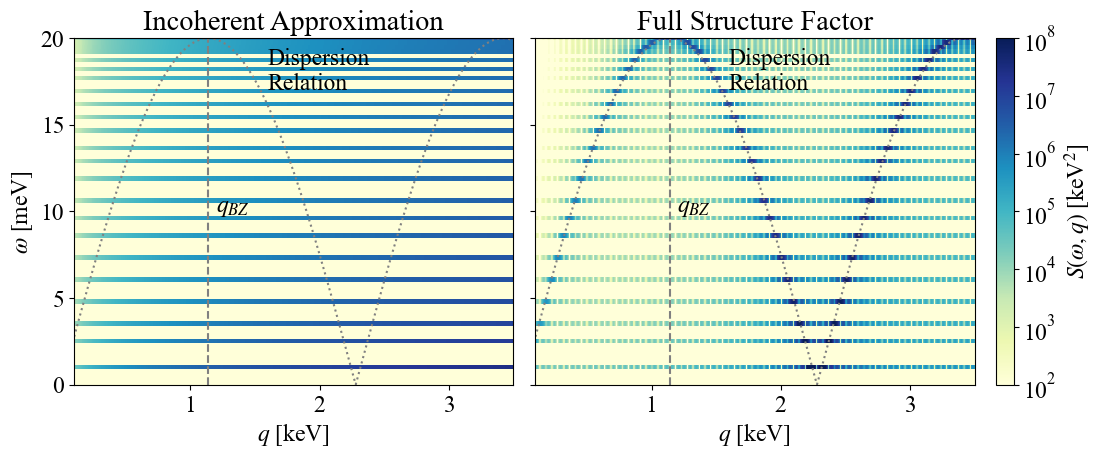

In [ ]:
# Create the figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
qplt_zoom, omgplt_zoom = np.meshgrid(q_list_zoom, omega_list_zoom)
plt.subplots_adjust(wspace=0.05)
# Common settings for both plots
norm = SymLogNorm(linthresh=0.1, vmin=1e2, vmax=1e8)
cmap = 'YlGnBu'

# --- Left Plot: Incoherent Approximation ---
pcm1 = ax1.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom_incoh.T, 
                      shading='nearest', cmap=cmap, norm=norm)
ax1.set_title("Incoherent Approximation")
ax1.set_ylabel("$\omega$ [meV]")

# --- Right Plot: Full Structure Factor ---
pcm2 = ax2.pcolormesh(qplt_zoom, omgplt_zoom, s_factor_zoom.T, 
                      shading='nearest', cmap=cmap, norm=norm)
ax2.set_title("Full Structure Factor")

# Annotations (Applying to both)
for ax in [ax1, ax2]:
    ax.set_xlabel("$q$ [keV]")
    ax.set_xlim(1e-1, 3.5)
    ax.set_ylim(0, 20.0)
    ax.axvline(qbz, color="gray", linestyle="--")
    ax.text(1.2, 10, r"$q_{BZ}$", color="black")
    ax.plot(x_zoom, y_zoom, color="gray", linestyle=":")
    ax.text(1.6, 17, "Dispersion\nRelation", color="black", fontsize=17)

# Create shared colorbar
# Use pcm2 (or pcm1) since they share the same norm and cmap
cbar = fig.colorbar(pcm2, ax=[ax1, ax2], location='right', pad=0.02)
cbar.set_label("$S(\omega,q)$ [keV$^2$]")

plt.show()